In [1]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).

In [5]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np


X,y=make_regression(n_samples=1000,n_features=5,noise=15,random_state=42)

In [6]:
model=LinearRegression()
kf=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X,y,cv=kf,scoring='r2')

In [7]:
print("R2 scores for each fold: ",scores.round(3))
print("Mean R2: ",scores.mean().round(3))
print("Standard Dev: ",scores.std().round(3))

R2 scores for each fold:  [0.937 0.945 0.945 0.947 0.947]
Mean R2:  0.944
Standard Dev:  0.004


In [8]:
if(scores.std()<0.05):
    print("Model is stable across folds")
else:
    print("Model needs to investigate more")

Model is stable across folds


In [9]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [18]:
X,y=make_regression(n_samples=1000,n_features=5,noise=500,random_state=42)

In [22]:
X

array([[ 2.05654356,  0.60685059,  0.48268789, -1.13088844,  0.42009449],
       [-0.79919201, -0.64596418, -0.18289644, -0.48274352,  1.37487642],
       [ 1.07600714, -0.79602586, -0.75196933,  0.02131165, -0.31905394],
       ...,
       [ 0.49968511,  0.2394045 ,  1.48724616,  0.47200227, -0.58005324],
       [-0.64148691,  0.01914778, -0.66198218,  0.48787228,  0.42588721],
       [ 0.91539028, -0.83305606, -1.77624633, -0.54954027, -0.08059975]])

In [24]:
model=LinearRegression()
kf=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X,y,cv=kf,scoring='r2')

In [25]:
print("R2 scores for each fold: ",scores.round(3))
print("Mean R2: ",scores.mean().round(3))
print("Standard Dev: ",scores.std().round(3))

R2 scores for each fold:  [ 0.019  0.002 -0.001 -0.009  0.009]
Mean R2:  0.004
Standard Dev:  0.009


In [26]:
if(scores.std()<0.05):
    print("Model is stable across folds")
else:
    print("Model needs to investigate more")

Model is stable across folds


In [ ]:
Scenario: Predicting Student Exam Performance
A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
- Number of study hours per week
- Attendance percentage in lectures
- Prior GPA (Grade Point Average)
- Participation in group projects (numeric engagement score)
- Average sleep hours during exam preparation
They collect data from 800 students across different departments and decide to use Linear Regression.
To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [39]:
X,y=make_regression(n_samples=800,n_features=5,noise=200,random_state=42)

In [40]:
model=LinearRegression()
kf=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X,y,cv=kf,scoring='r2')

In [41]:
print("R2 scores for each fold: ",scores.round(3))
print("Mean R2: ",scores.mean().round(3))
print("Standard Dev: ",scores.std().round(3))

R2 scores for each fold:  [0.328 0.339 0.308 0.316 0.298]
Mean R2:  0.318
Standard Dev:  0.014


In [42]:
if(scores.std()<0.05):
    print("Model is stable across folds")
else:
    print("Model needs to investigate more")

Model is stable across folds


In [43]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

In [44]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [48]:
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30) 

In [49]:
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression())

In [50]:
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

In [51]:
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)


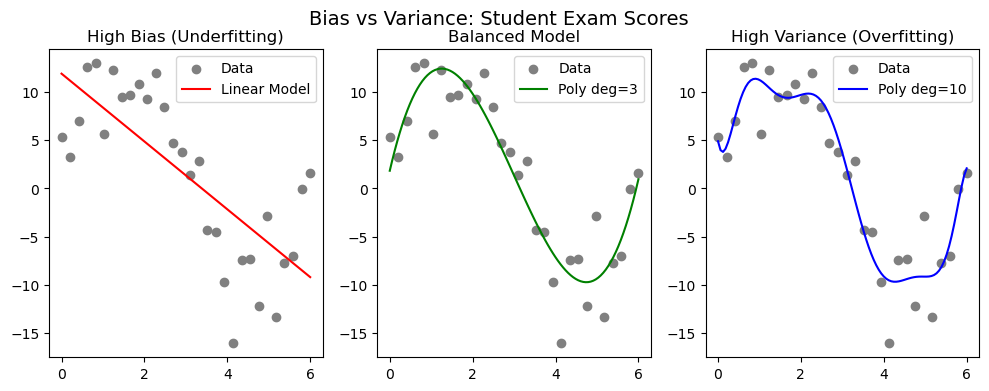

In [52]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

In [53]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?

In [66]:
np.random.seed(0)
X = np.linspace(0, 15, 30).reshape(-1, 1)
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30) 

In [67]:
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression())

In [68]:
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

In [69]:
X_test = np.linspace(0, 20, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

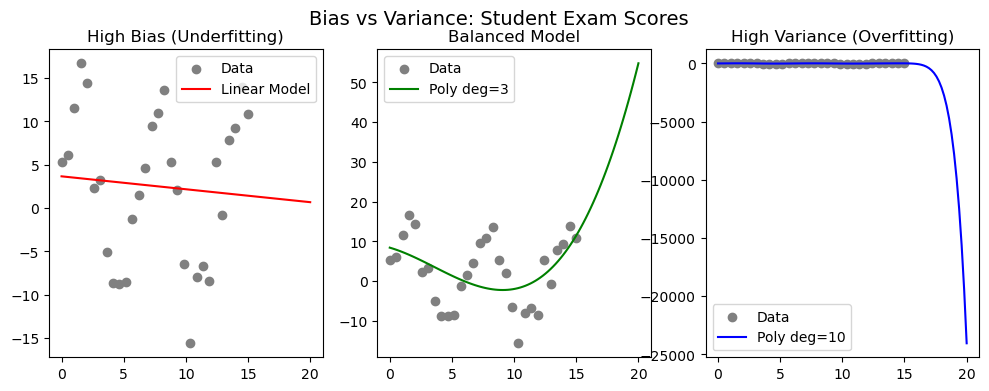

In [70]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

In [71]:
# Scenario: Package Delivery System
# A logistics company wants to build a machine learning model to optimize package delivery.
# They collect data about each package, including:
# - Size: Small, Medium, Large
# - Priority: Low, Medium, High
# Since machine learning models work with numbers (not text labels), the company decides to use Label
#  Encoding to convert these categories into numeric values.
# They apply Scikit-learn’s LabelEncoder to both features:
# - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
# - Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)
# They also check the mapping and decode the numbers back to the original labels to ensure correctness.

# Questions for Learners
# Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers 
# before training a model?
# Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2) 
# matter for all models? Why or why not?
# Part C: How can the company decode the numeric values back into the original labels after prediction?
# Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle 
# this, and what challenge might arise if the model was already trained?

In [75]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

In [76]:
le_size=LabelEncoder()
data['Size_Encoded']=le_size.fit_transform(data['Size'])

In [77]:
le_priority=LabelEncoder()
data['Priority_Encoded']=le_priority.fit_transform(data['Priority'])

In [78]:
print('size mapping: ',dict(zip(le_size.classes_,le_size.transform(le_size.classes_))))
print('Priority mapping: ',dict(zip(le_priority.classes_,le_priority.transform(le_priority.classes_))))


size mapping:  {'Large': 0, 'Medium': 1, 'Small': 2}
Priority mapping:  {'High': 0, 'Low': 1, 'Medium': 2}


In [79]:
decoded_size=le_size.inverse_transform([0,1,2])
print('Decoded Size: ',decoded_size)

Decoded Size:  ['Large' 'Medium' 'Small']


In [80]:
print('\nEncoded DataFrame: ')
print(data)


Encoded DataFrame: 
     Size Priority  Size_Encoded  Priority_Encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0


In [81]:
# Scenario: Restaurant Ordering System
# A restaurant wants to build a machine learning model to predict order preparation time.
# They collect data about each order, including:
# - Meal Type: Breakfast, Lunch, Dinner
# - Spice Level: Mild, Medium, Hot
# Since models can’t directly work with text labels, the restaurant uses Label Encoding to 
# convert these categories into numbers.

In [82]:
data = pd.DataFrame({
    'Meal': ['breakfast', 'lunch', 'breakfast', 'dinner', 'dinner','lunch','lunch','dinner','breakfast'],
    'Spice': ['Mild', 'Hot', 'Medium', 'Mild', 'Mild','Hot','Hot','Medium','Medium']
})

In [83]:
le_meal=LabelEncoder()
data['Meal_Encoded']=le_meal.fit_transform(data['Meal'])

In [84]:
le_spice=LabelEncoder()
data['Spice_Encoded']=le_spice.fit_transform(data['Spice'])

In [86]:
print('Meal mapping: ',dict(zip(le_meal.classes_,le_meal.transform(le_meal.classes_))))
print('Spice mapping: ',dict(zip(le_spice.classes_,le_spice.transform(le_spice.classes_))))

Meal mapping:  {'breakfast': 0, 'dinner': 1, 'lunch': 2}
Spice mapping:  {'Hot': 0, 'Medium': 1, 'Mild': 2}


In [88]:
decoded_meal=le_size.inverse_transform([0,1,2])
print('Decoded Size: ',decoded_meal)

Decoded Size:  ['Large' 'Medium' 'Small']


In [89]:
print('\nEncoded DataFrame: ')
print(data)


Encoded DataFrame: 
        Meal   Spice  Meal_Encoded  Spice_Encoded
0  breakfast    Mild             0              2
1      lunch     Hot             2              0
2  breakfast  Medium             0              1
3     dinner    Mild             1              2
4     dinner    Mild             1              2
5      lunch     Hot             2              0
6      lunch     Hot             2              0
7     dinner  Medium             1              1
8  breakfast  Medium             0              1


In [90]:
# Scenario: Employee Training & Satisfaction Survey
# A company conducts a survey to understand how employee education level and job satisfaction affect performance.
# They collect data such as:
# - Education: High School, Bachelor, Master, PhD
# - Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
#  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect 
#  this ranking.
# They define custom ordering:
# - Education → High School (0), Bachelor (1), Master (2), PhD (3)
# - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

# Questions for Learners
# Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered 
# categories like education level?
# Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in 
# interpreting the model?
# Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?
# Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they 
# update their encoding scheme to keep the order meaningful?

In [91]:
data=pd.DataFrame({'Education':['Bachelor','PhD','Master','HighSchool'],
                  'Satisfaction':['Good','Excellent','Poor','Average']})
education_order=[['HighSchool','Bachelor','Master','PhD']]
sat_order=[['Poor','Average','Good','Excellent']]


In [95]:
from sklearn.preprocessing import OrdinalEncoder
edu_encoder=OrdinalEncoder(categories=education_order)
data['Education_Encoded']=edu_encoder.fit_transform(data[['Education']])
sat_encoder=OrdinalEncoder(categories=sat_order)
data['Satisfaction_Encoded']=sat_encoder.fit_transform(data[['Satisfaction']])

In [96]:
edu_map={'HighSchool':0,'Bachelor':1,'Master':2,'PhD':3}
sat_map={'Poor':0,'Average':1,'Good':2,'Excellent':3}


In [97]:
data['Education_Manual']=data['Education'].map(edu_map)
data['Satisfaction_Manual']=data['Satisfaction'].map(sat_map)

In [100]:
data

,Education,Satisfaction,Education_Encoded,Satisfaction_Encoded,Education_Manual,Satisfaction_Manual
0,Bachelor,Good,1.0,2.0,1,2
1,PhD,Excellent,3.0,3.0,3,3
2,Master,Poor,2.0,0.0,2,0
3,HighSchool,Average,0.0,1.0,0,1


In [101]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery 
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is 
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

In [113]:
data=pd.DataFrame({'Severity':['Mild','Moderate','severe','Critical'],
                  'Satisfaction':['Good','Excellent','Poor','Average']})
severe_order=[['Mild','Moderate','severe','Critical']]
sat_order=[['Poor','Average','Good','Excellent']]


In [114]:
severe_encoder=OrdinalEncoder(categories=severe_order)
data['Severity_Encoded']=severe_encoder.fit_transform(data[['Severity']])
sat_encoder=OrdinalEncoder(categories=sat_order)
data['Satisfaction_Encoded']=sat_encoder.fit_transform(data[['Satisfaction']])

In [116]:
severe_map={'Mild':0,'Moderate':1,'severe':2,'Critucal':3}
sat_map={'Poor':0,'Average':1,'Good':2,'Excellent':3}


In [117]:
data['Severe_Manual']=data['Severity'].map(severe_map)
data['Satisfaction_Manual']=data['Satisfaction'].map(sat_map)

In [118]:
data

,Severity,Satisfaction,Severity_Encoded,Satisfaction_Encoded,Severe_Manual,Satisfaction_Manual
0,Mild,Good,0.0,2.0,0.0,2
1,Moderate,Excellent,1.0,3.0,1.0,3
2,severe,Poor,2.0,0.0,2.0,0
3,Critical,Average,3.0,1.0,NaN,1


In [ ]:
# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?

In [119]:
from sklearn.preprocessing import OneHotEncoder


In [121]:
orders=pd.DataFrame({'Cuisine':['Italian','Chinese','Indian','Mexiacn','Chinese','Italian']})
encoder=OneHotEncoder(sparse_output=False)
encoded_array=encoder.fit_transform(orders[['Cuisine']])
encoded_df=pd.DataFrame(encoded_array,columns=encoder.categories_[0])

In [125]:
final_data=pd.concat([orders,encoded_df],axis=1)
print("Cuisine categories: ",encoder.categories_)
print("\nENcoded Array : ",encoded_array)
print("\nFinal Encoded DataFrame: ",final_data)


Cuisine categories:  [array(['Chinese', 'Indian', 'Italian', 'Mexiacn'], dtype=object)]

ENcoded Array :  [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]

Final Encoded DataFrame:     Cuisine  Chinese  Indian  Italian  Mexiacn
0  Italian      0.0     0.0      1.0      0.0
1  Chinese      1.0     0.0      0.0      0.0
2   Indian      0.0     1.0      0.0      0.0
3  Mexiacn      0.0     0.0      0.0      1.0
4  Chinese      1.0     0.0      0.0      0.0
5  Italian      0.0     0.0      1.0      0.0
